In [14]:
!pip install yfinance scikit-learn

In [22]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [23]:
stock = "AAPL"   # Change stock symbol if needed
data = yf.download(stock, start="2020-01-01", end="2024-01-01")
data.head()


C:\Users\hp\AppData\Local\Temp\ipykernel_3056\3336147002.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock, start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.468262,72.528582,71.223259,71.476600,135480400
2020-01-03,71.763725,72.523754,71.539337,71.696167,146322800
2020-01-06,72.335556,72.374162,70.634539,70.885472,118387200
2020-01-07,71.995354,72.600960,71.775789,72.345204,108872000
2020-01-08,73.153488,73.455087,71.698574,71.698574,132079200


In [24]:
df = data.copy()

# Create target column (next day's close)
df["Next_Close"] = df["Close"].shift(-1)

# Remove the last row (no next day available)
df = df.dropna()


In [25]:
X = df[["Open", "High", "Low", "Volume"]]
y = df["Next_Close"]

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


In [27]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [28]:
pred = model.predict(X_test)

In [29]:
mse = mean_squared_error(y_test, pred)
print("Mean Squared Error:", mse)


Mean Squared Error: 4.955222160481815


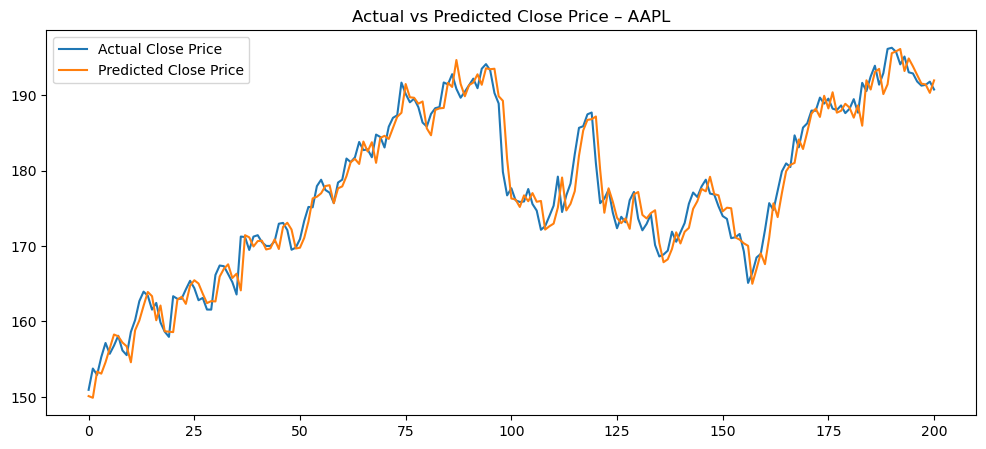

In [31]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual Close Price")
plt.plot(pred, label="Predicted Close Price")
plt.legend()
plt.title(f"Actual vs Predicted Close Price – {stock}")
plt.show()
